<a href="https://colab.research.google.com/github/HumairaKhan3105/OBISIP-Data_Science_internship/blob/main/OIBSIP_1%20Unemployement_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_squared_error,  mean_absolute_error,  r2_score


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Unemployment in India.csv")

In [ ]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [ ]:
df.fillna(method='ffill',inplace=True)

/tmp/ipykernel_842/4116506308.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df[' Frequency'].value_counts()
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df = df.copy()

df[['Day','month','year']] = df[' Date'].str.split("-", expand=True)

In [ ]:
df.loc[:, ['Day','month','year']] = df[' Date'].str.split("-", expand=True)
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Day,month,year
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,NaN,NaN,NaN
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban,NaN,NaN,NaN
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban,NaN,NaN,NaN
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban,NaN,NaN,NaN
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Region', 'Date', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Day', 'month', 'year', 'Year'],
      dtype='object')

In [ ]:
df['Year'] = pd.to_datetime(df['year'], format='%Y')

print(df.dtypes)

Region                                             object
Date                                               object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Day                                                object
month                                              object
year                                               object
Year                                       datetime64[ns]
dtype: object


In [ ]:
print(df.describe())

        Estimated Unemployment Rate (%)   Estimated Employed  \
count                        740.000000         7.400000e+02   
mean                          11.787946         7.204460e+06   
min                            0.000000         4.942000e+04   
25%                            4.657500         1.190404e+06   
50%                            8.350000         4.744178e+06   
75%                           15.887500         1.127549e+07   
max                           76.740000         4.577751e+07   
std                           10.721298         8.087988e+06   

        Estimated Labour Participation Rate (%) Year  
count                                740.000000    0  
mean                                  42.630122  NaT  
min                                   13.330000  NaT  
25%                                   38.062500  NaT  
50%                                   41.160000  NaT  
75%                                   45.505000  NaT  
max                                   

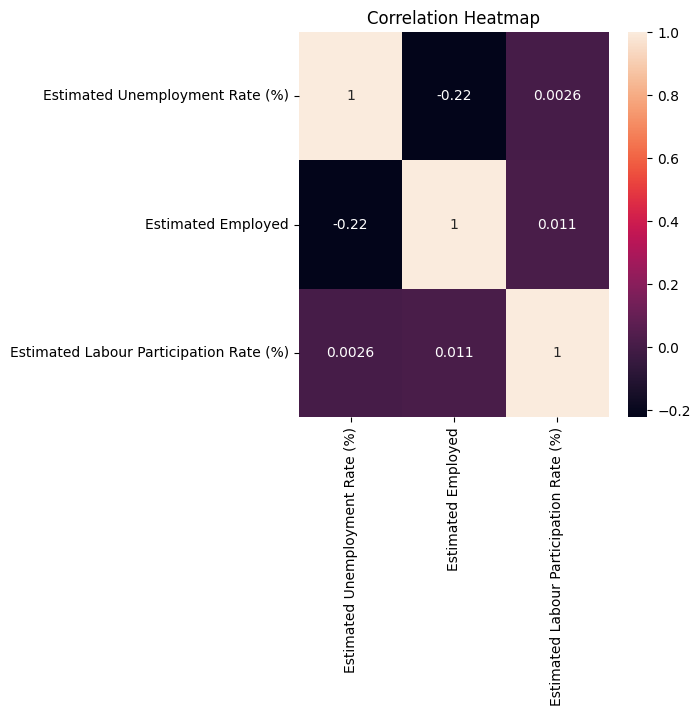

In [ ]:
numeric_df = df.select_dtypes(include = [np.number])

plt.figure(figsize=(5,5))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

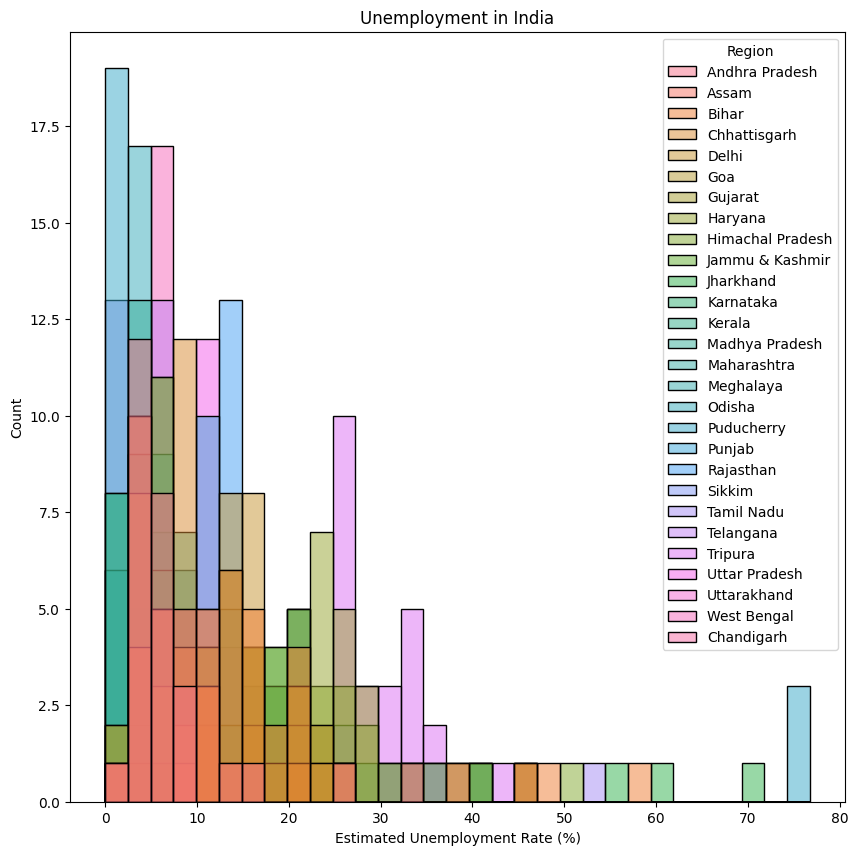

In [ ]:


df.columns = df.columns.str.strip()

plt.figure(figsize=(10,10))
plt.title("Unemployment in India")

sns.histplot(
    data=df,
    x='Estimated Unemployment Rate (%)',
    hue='Region',
    kde=False
)

plt.show()

In [ ]:
df.month.unique()





array([nan], dtype=object)

In [ ]:
print(df[['month', 'Year', 'Estimated Unemployment Rate (%)']].head())
print(df[['month', 'Year', 'Estimated Unemployment Rate (%)']].isnull().sum())

  month Year  Estimated Unemployment Rate (%)
0   NaN  NaT                             3.65
1   NaN  NaT                             3.05
2   NaN  NaT                             3.75
3   NaN  NaT                             3.32
4   NaN  NaT                             5.17
month                              740
Year                               740
Estimated Unemployment Rate (%)      0
dtype: int64


In [ ]:
print(df['Date'].head())

0     31-05-2019
1     30-06-2019
2     31-07-2019
3     31-08-2019
4     30-09-2019
Name: Date, dtype: object


In [ ]:
df.columns = df.columns.str.strip()

df['Date'] = df['Date'].str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

print(df[['Date', 'month', 'year']].head())

        Date  month  year
0 2019-05-31      5  2019
1 2019-06-30      6  2019
2 2019-07-31      7  2019
3 2019-08-31      8  2019
4 2019-09-30      9  2019


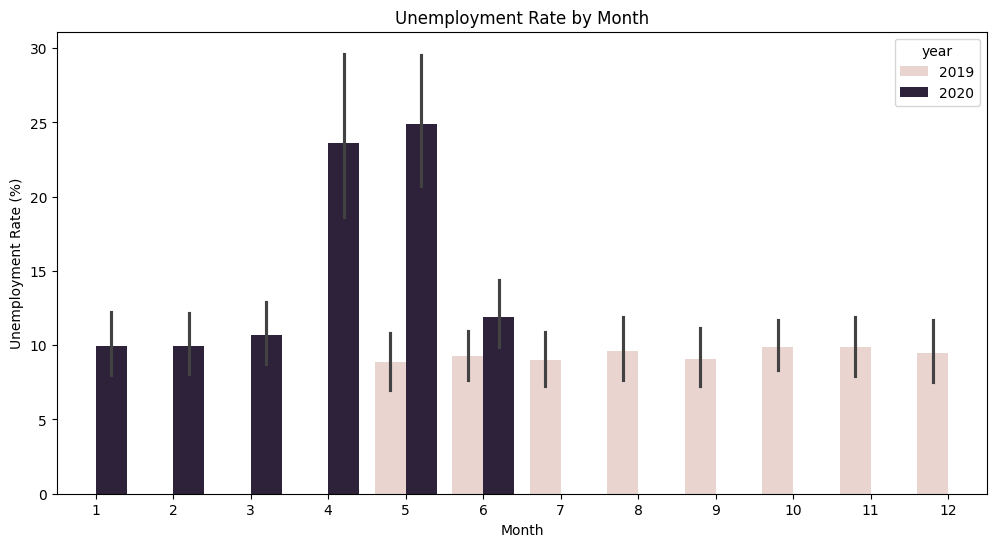

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='month',
    y='Estimated Unemployment Rate (%)',
    hue='year'
)

plt.title("Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [ ]:
df['Day'] = df['Date'].dt.day

In [ ]:
print(df[['Day','year']].dtypes)

Day     int32
year    int32
dtype: object


In [ ]:
df.Day.unique()


array([31, 30, 29], dtype=int32)

<Axes: xlabel='Day', ylabel='Estimated Unemployment Rate (%)'>

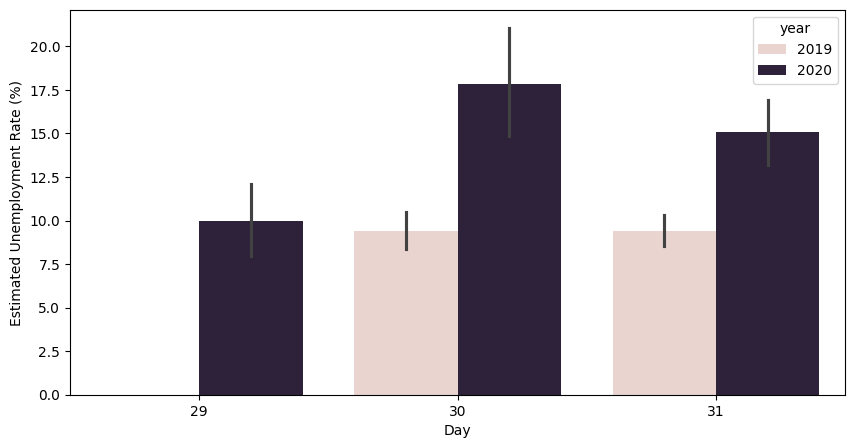

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Day',y='Estimated Unemployment Rate (%)',hue = 'year',data = df)


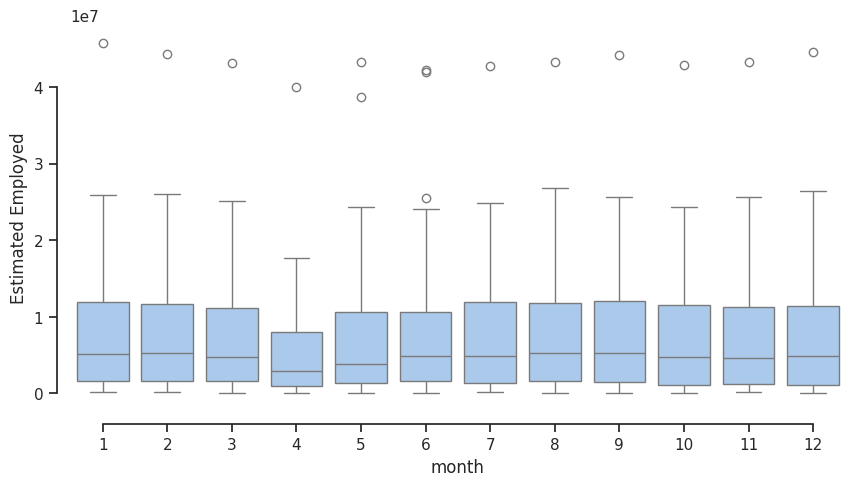

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='month',
    y='Estimated Employed'
)

sns.despine(offset=10, trim=True)
plt.show()

In [ ]:
df.drop('Year',axis = 1)

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Day,month,year
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural,31,5,2019
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural,30,6,2019
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural,31,7,2019
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural,31,8,2019
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural,30,9,2019
...,...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,7.55,10871168.0,44.09,Urban,29,2,2020
750,West Bengal,2020-03-31,6.67,10806105.0,43.34,Urban,31,3,2020
751,West Bengal,2020-04-30,15.63,9299466.0,41.20,Urban,30,4,2020
752,West Bengal,2020-05-31,15.22,9240903.0,40.67,Urban,31,5,2020


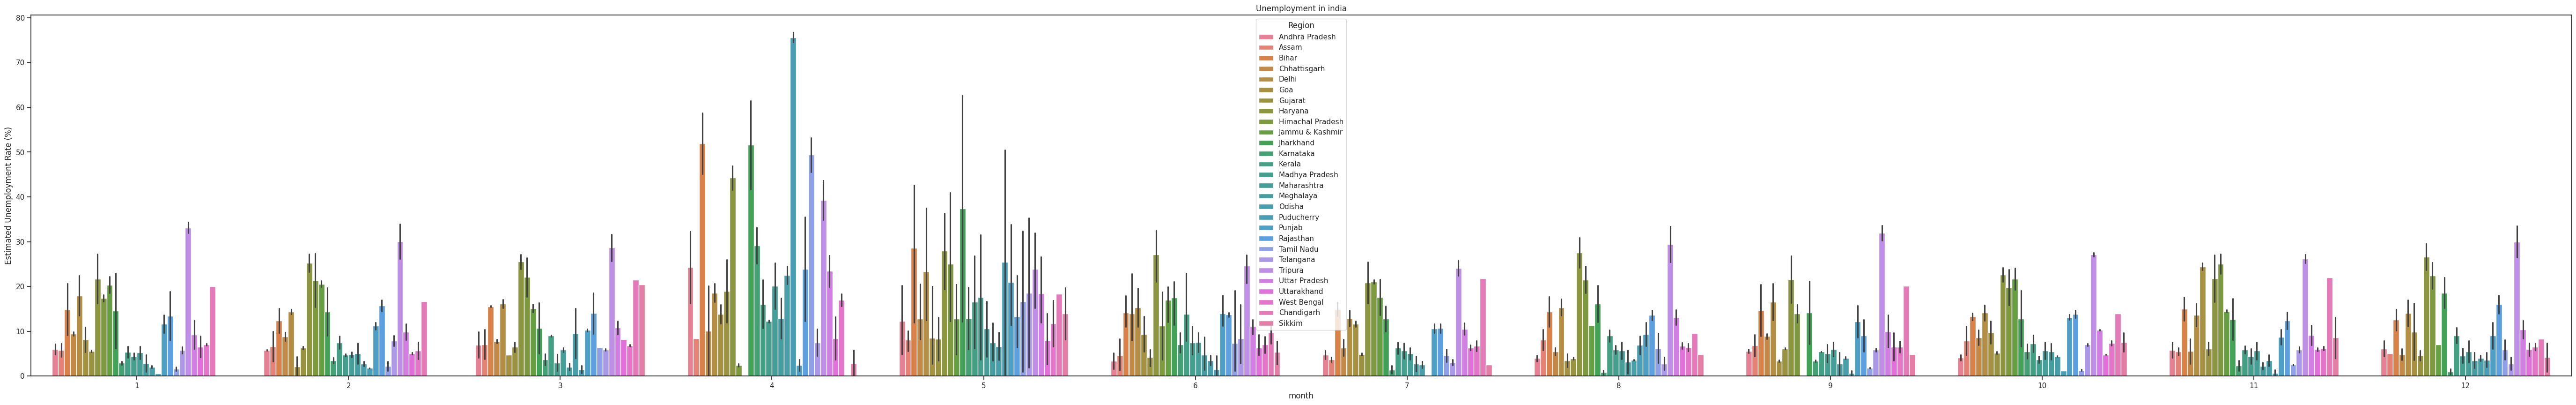

In [ ]:
plt.figure(figsize=(70,10))
plt.title("Unemployment in india")

sns.barplot(
    data=df,
    x='month',
    y='Estimated Unemployment Rate (%)',
    hue = 'Region'
)

plt.show()

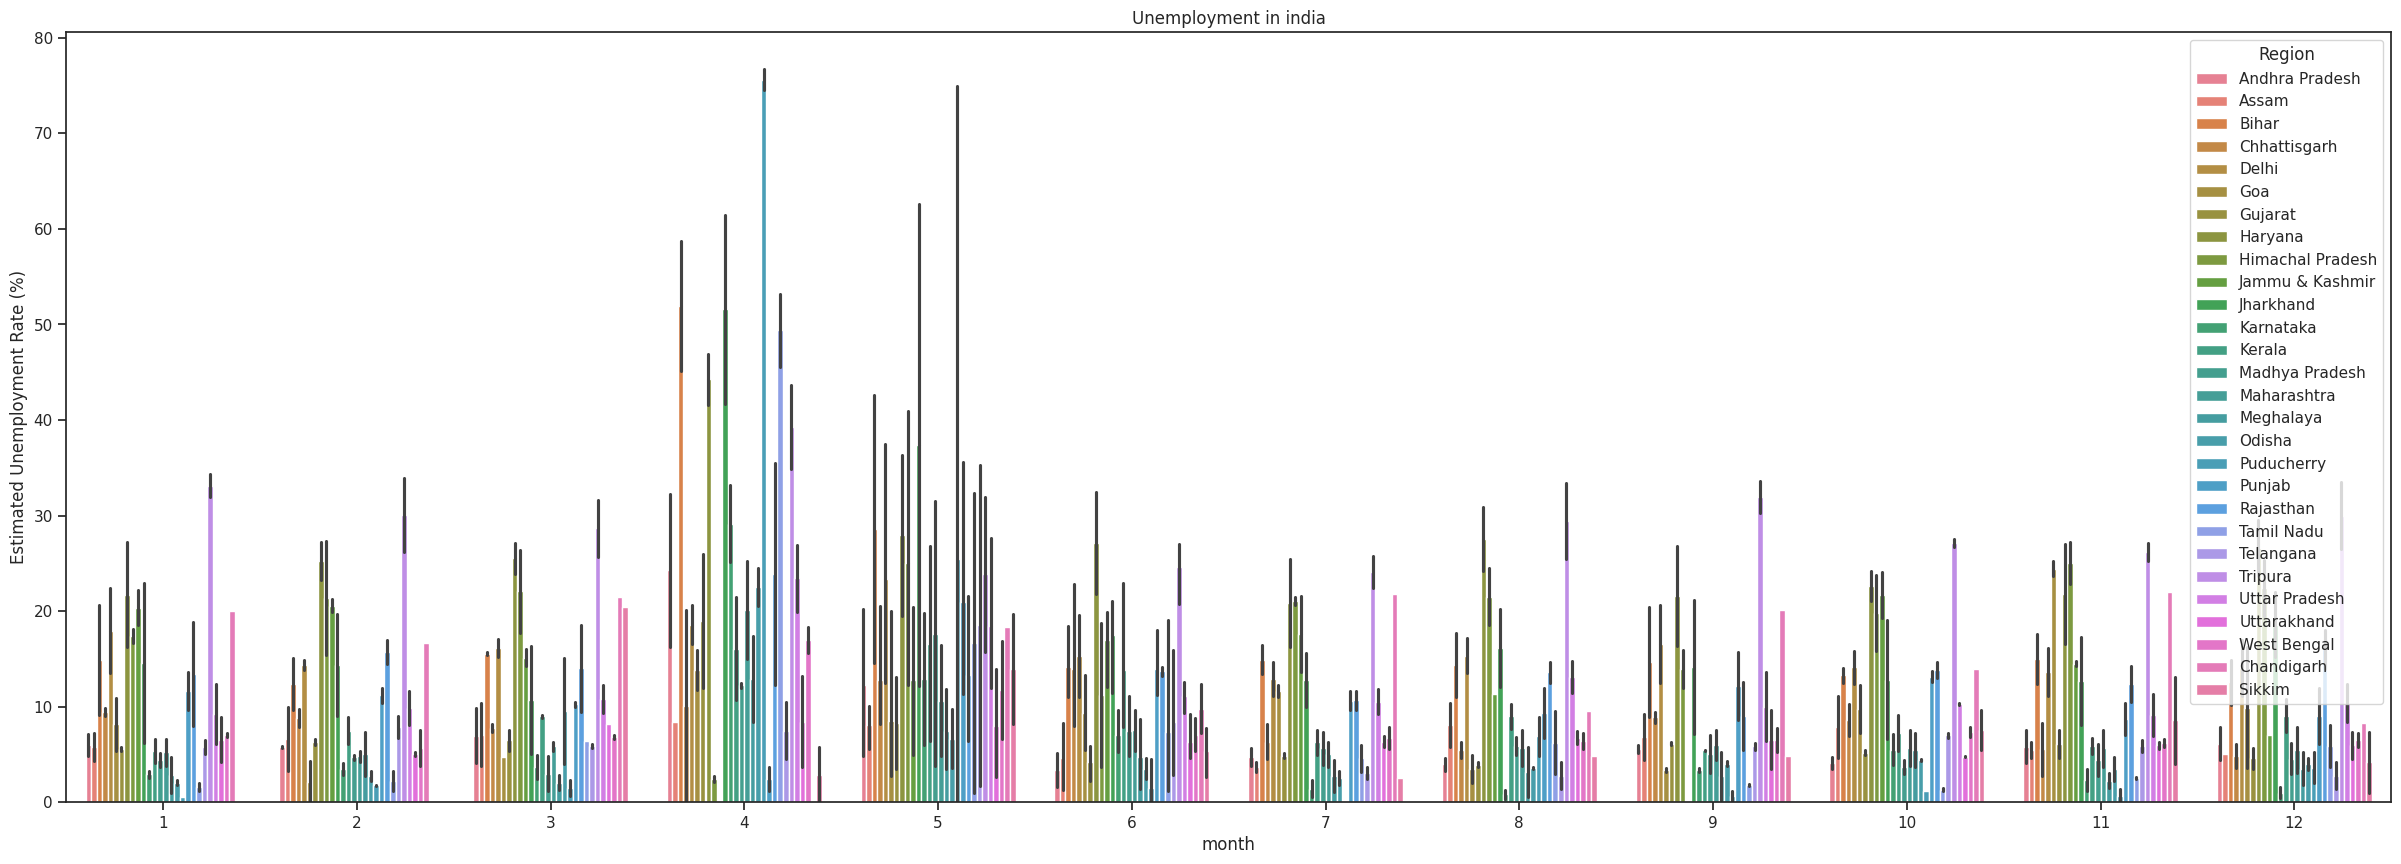

In [ ]:
plt.figure(figsize=(30,10))
plt.title("Unemployment in india")

sns.barplot(
    data=df,
    x='month',
    y='Estimated Unemployment Rate (%)',
    hue = 'Region'
)

plt.show()

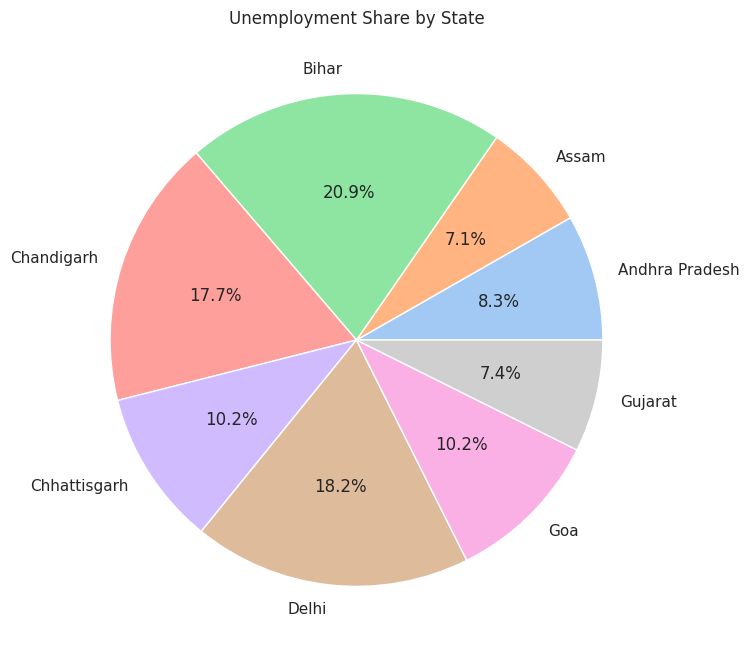

In [ ]:
plt.figure(figsize=(8,8))

state_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

plt.pie(
    state_unemp.head(8),
    labels=state_unemp.head(8).index,
    autopct='%1.1f%%'
)

plt.title("Unemployment Share by State")
plt.show()

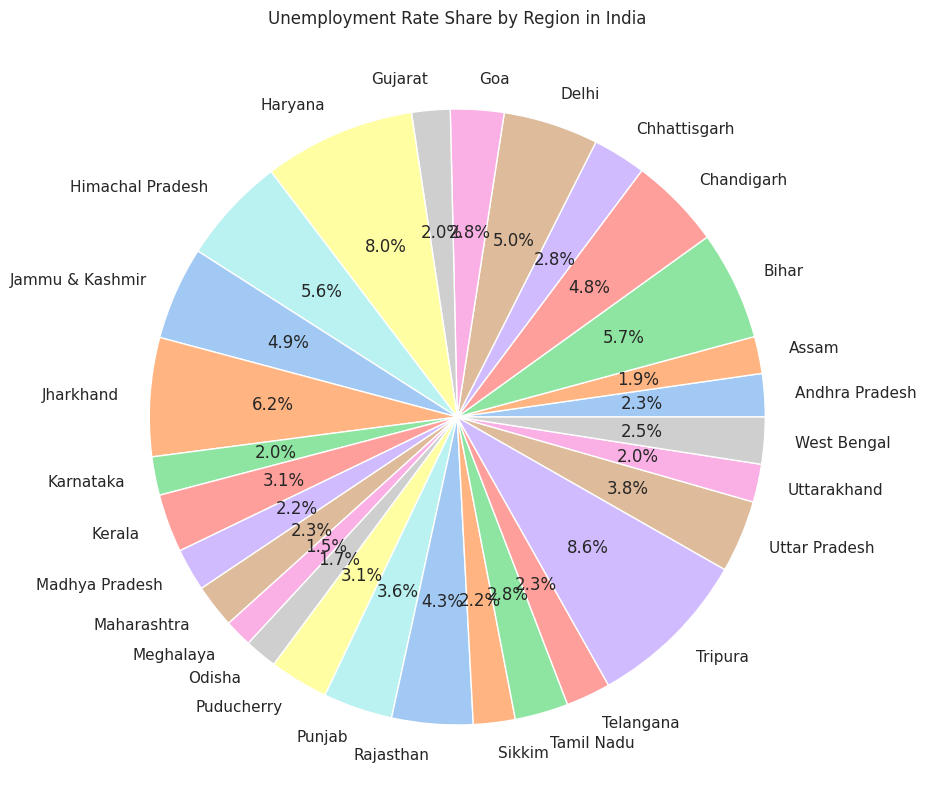

In [ ]:
import matplotlib.pyplot as plt

# Region-wise average unemployment rate
region_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,10))

plt.pie(
    region_unemp,
    labels=region_unemp.index,
    autopct='%1.1f%%'
)

plt.title("Unemployment Rate Share by Region in India")
plt.show()

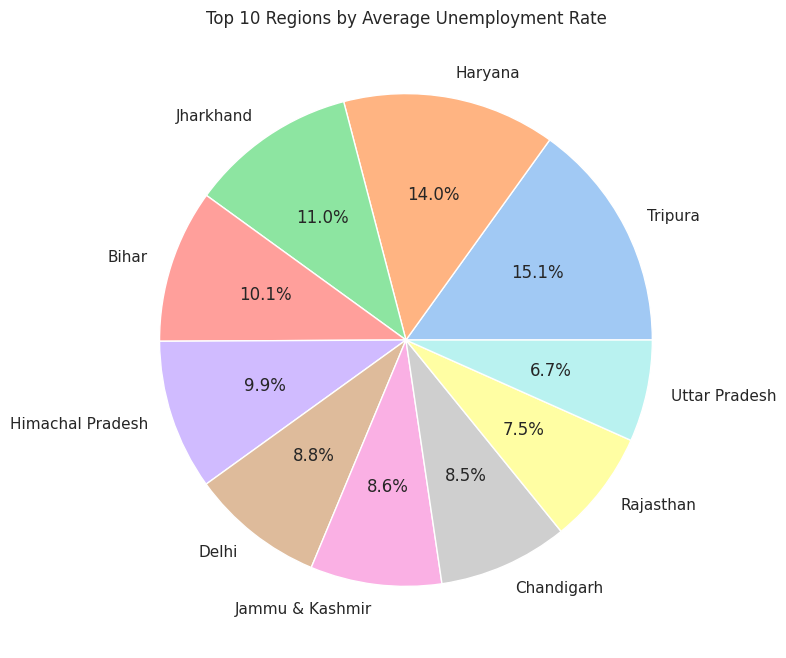

In [ ]:
import matplotlib.pyplot as plt

top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct='%1.1f%%'
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.show()